# 📚 Task 1: Pattern & Graph Analysis
## Course Enrollment Data — Apriori, FP-Growth, PageRank
**Dataset:** HarvardX / MITx Coursera enrollment records  
**Goal:** Discover common course combinations and influential courses

---
### Pipeline Overview
```
Cleaned_Enrollments.csv
       │
       ├──► Build Transaction Matrix (users × courses)
       │         │
       │    ┌────▼──────────────────────────────────┐
       │    │  Task 1A: Apriori Algorithm           │
       │    │  → frequent_itemsets.csv              │
       │    │  → association_rules.csv              │
       │    └───────────────────────────────────────┘
       │         │
       │    ┌────▼──────────────────────────────────┐
       │    │  Task 1B: FP-Growth Algorithm         │
       │    │  → fp_frequent_itemsets.csv           │
       │    │  → fp_rules.csv                      │
       │    └───────────────────────────────────────┘
       │         │
       │    ┌────▼──────────────────────────────────┐
            │  Task 1C: PageRank / Link Analysis    │
            │  → course_graph_edges.csv             │
            │  → pagerank_scores.csv               │
            └───────────────────────────────────────┘
```

In [1]:
# ── Cell 1: Imports & Setup ──────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import networkx as nx
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules, fpgrowth
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({'figure.dpi': 120, 'axes.spines.top': False, 'axes.spines.right': False})
PALETTE = ['#1C7293', '#028090', '#02C39A', '#F96167', '#F9E795', '#2F3C7E', '#065A82', '#21295C']
print('✅ Libraries loaded')

✅ Libraries loaded


In [2]:
# ── Cell 2: Load & Explore Data ─────────────────────────────────────────
import os
from google.colab import files

if not os.path.exists('/content/Cleaned_Enrollments.csv'):
    print('📤 Please upload Cleaned_Enrollments.csv')
    uploaded = files.upload()

enrollments = pd.read_csv('/content/Cleaned_Enrollments.csv')
print('Shape:', enrollments.shape)
print('Columns:', enrollments.columns.tolist())
print(f'Unique users:   {enrollments["userid_DI"].nunique():,}')
print(f'Unique courses: {enrollments["course_name"].nunique()}')
enrollments.head()

📤 Please upload Cleaned_Enrollments.csv


Saving Cleaned_Enrollments.csv to Cleaned_Enrollments.csv
Shape: (641138, 4)
Columns: ['course_id', 'userid_DI', 'course_name', 'course_description']
Unique users:   476,532
Unique courses: 13


,course_id,userid_DI,course_name,course_description
0,HarvardX/CB22x/2013_Spring,MHxPC130442623,Justice,An introductory course in moral and political ...
1,HarvardX/CS50x/2012,MHxPC130442623,CS50: Introduction to Computer Science,Harvard University introduction to computer sc...
2,HarvardX/CB22x/2013_Spring,MHxPC130275857,Justice,An introductory course in moral and political ...
3,HarvardX/CS50x/2012,MHxPC130275857,CS50: Introduction to Computer Science,Harvard University introduction to computer sc...
4,HarvardX/ER22x/2013_Spring,MHxPC130275857,Health in Numbers: Quantitative Methods,An introduction to epidemiology and biostatist...


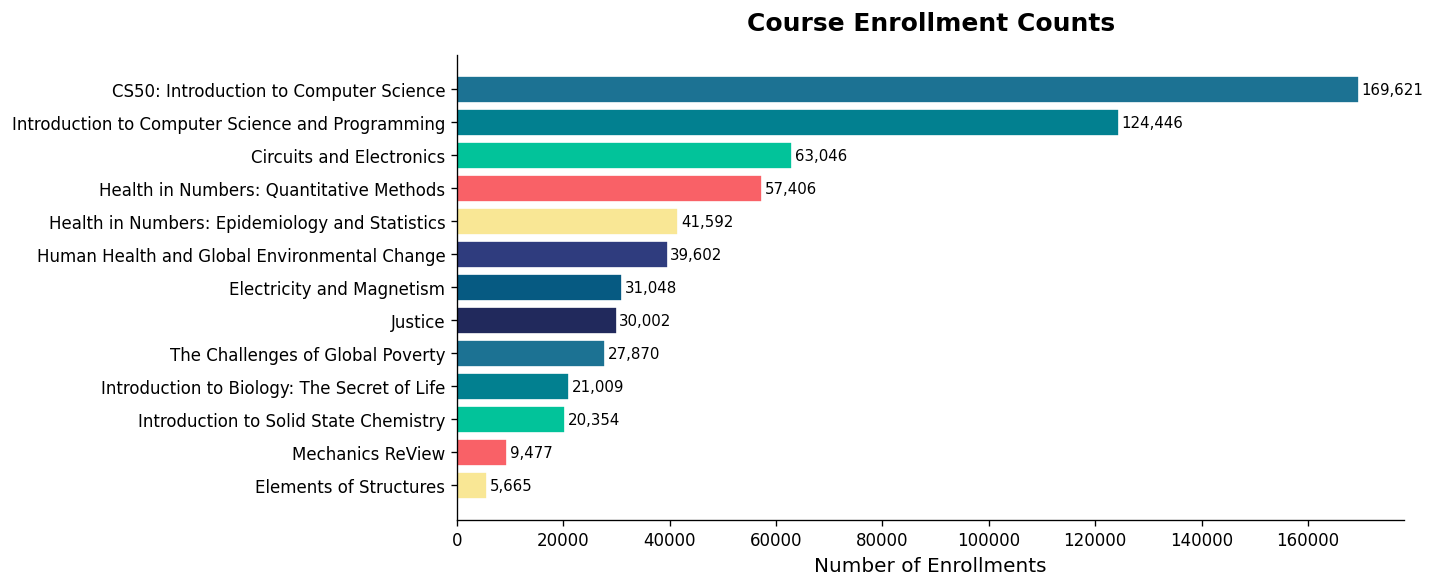

In [3]:
# ── Cell 3: Visualize — Course Enrollment Counts ────────────────────────
course_counts = enrollments['course_name'].value_counts()

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.barh(course_counts.index, course_counts.values,
               color=PALETTE[:len(course_counts)], edgecolor='white')
ax.set_xlabel('Number of Enrollments', fontsize=12)
ax.set_title('Course Enrollment Counts', fontsize=15, fontweight='bold', pad=15)
for bar, val in zip(bars, course_counts.values):
    ax.text(val + 500, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', fontsize=9)
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('viz_enrollment_counts.png', bbox_inches='tight')
plt.show()

In [4]:
# ── Cell 4: Build Transaction Matrix ────────────────────────────────────
transactions = enrollments.groupby('userid_DI')['course_name'].apply(list).tolist()
print(f'Transactions (users): {len(transactions):,}')
print(f'Sample: {transactions[0]}')

te = TransactionEncoder()
te_array = te.fit_transform(transactions)
df_te = pd.DataFrame(te_array, columns=te.columns_)
print(f'Matrix shape: {df_te.shape}')
df_te.head()

Transactions (users): 476,532
Sample: ['Human Health and Global Environmental Change', 'The Challenges of Global Poverty']
Matrix shape: (476532, 13)


,CS50: Introduction to Computer Science,Circuits and Electronics,Electricity and Magnetism,Elements of Structures,Health in Numbers: Epidemiology and Statistics,Health in Numbers: Quantitative Methods,Human Health and Global Environmental Change,Introduction to Biology: The Secret of Life,Introduction to Computer Science and Programming,Introduction to Solid State Chemistry,Justice,Mechanics ReView,The Challenges of Global Poverty
0,False,False,False,False,False,False,True,False,False,False,False,False,True
1,False,False,False,False,False,False,False,False,False,False,False,False,True
2,True,False,False,False,False,True,False,False,False,False,False,False,False
3,False,False,False,False,False,True,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,True,False,False


In [5]:
# ── Cell 5: APRIORI — Frequent Itemsets ─────────────────────────────────
frequent_itemsets = apriori(df_te, min_support=0.01, use_colnames=True)
frequent_itemsets['length'] = frequent_itemsets['itemsets'].apply(len)
frequent_itemsets['count'] = (frequent_itemsets['support'] * len(df_te)).round().astype(int)
frequent_itemsets = frequent_itemsets.sort_values('support', ascending=False).reset_index(drop=True)
print(f'Frequent itemsets found: {len(frequent_itemsets)}')
frequent_itemsets.head(10)

Frequent itemsets found: 27


,support,itemsets,length,count
0,0.355949,(CS50: Introduction to Computer Science),1,169621
1,0.256086,(Introduction to Computer Science and Programm...,1,122033
2,0.126940,(Circuits and Electronics),1,60491
3,0.120466,(Health in Numbers: Quantitative Methods),1,57406
4,0.087281,(Health in Numbers: Epidemiology and Statistics),1,41592
5,0.084158,(Introduction to Computer Science and Programm...,2,40104
6,0.083105,(Human Health and Global Environmental Change),1,39602
7,0.065154,(Electricity and Magnetism),1,31048
8,0.062959,(Justice),1,30002
9,0.058485,(The Challenges of Global Poverty),1,27870


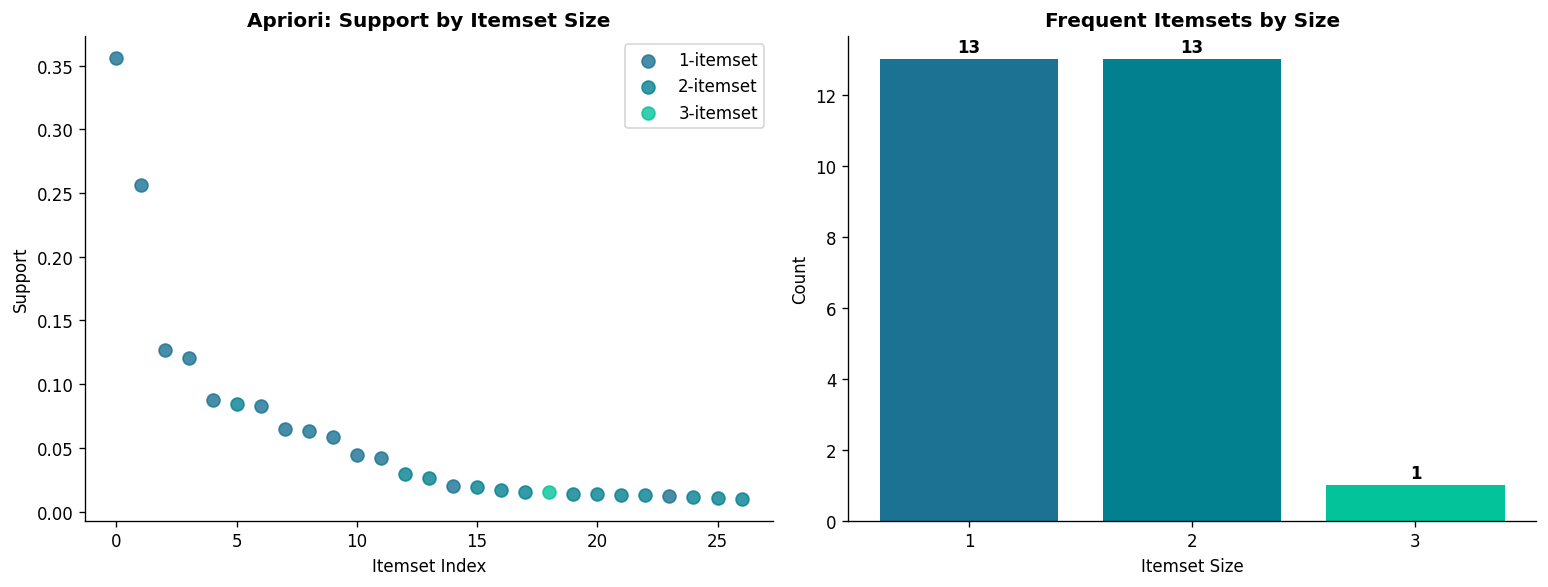

In [6]:
# ── Cell 6: Visualize — Support Distribution (Apriori) ──────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: support by itemset size
for length, grp in frequent_itemsets.groupby('length'):
    axes[0].scatter(grp.index, grp['support'], label=f'{length}-itemset',
                    s=60, alpha=0.8, color=PALETTE[length-1])
axes[0].set_xlabel('Itemset Index')
axes[0].set_ylabel('Support')
axes[0].set_title('Apriori: Support by Itemset Size', fontweight='bold')
axes[0].legend()

# Right: count of itemsets per size
size_counts = frequent_itemsets['length'].value_counts().sort_index()
axes[1].bar(size_counts.index.astype(str), size_counts.values, color=PALETTE[:len(size_counts)])
axes[1].set_xlabel('Itemset Size')
axes[1].set_ylabel('Count')
axes[1].set_title('Frequent Itemsets by Size', fontweight='bold')
for i, v in enumerate(size_counts.values):
    axes[1].text(i, v + 0.2, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('viz_apriori_support.png', bbox_inches='tight')
plt.show()

In [7]:
# ── Cell 7: APRIORI — Association Rules ──────────────────────────────────
rules = association_rules(frequent_itemsets, metric='confidence', min_threshold=0.05)
rules['certainty_factor'] = (rules['confidence'] - rules['support']) / (1 - rules['support'])
rules['count'] = (rules['support'] * len(df_te)).round().astype(int)
rules = rules.sort_values('lift', ascending=False).reset_index(drop=True)
rules['antecedents'] = rules['antecedents'].apply(str)
rules['consequents'] = rules['consequents'].apply(str)
print(f'Rules found: {len(rules)}')
rules[['antecedents','consequents','support','confidence','lift','leverage','conviction','certainty_factor','count']].head(10)

Rules found: 27


,antecedents,consequents,support,confidence,lift,leverage,conviction,certainty_factor,count
0,frozenset({'Human Health and Global Environmen...,frozenset({'The Challenges of Global Poverty'}),0.011185,0.134589,2.301257,0.006325,1.087940,0.124800,5330
1,frozenset({'The Challenges of Global Poverty'}),frozenset({'Human Health and Global Environmen...,0.011185,0.191245,2.301257,0.006325,1.133712,0.182097,5330
2,frozenset({'Circuits and Electronics'}),frozenset({'Electricity and Magnetism'}),0.018998,0.149659,2.296996,0.010727,1.099377,0.133191,9053
3,frozenset({'Electricity and Magnetism'}),frozenset({'Circuits and Electronics'}),0.018998,0.291581,2.296996,0.010727,1.232406,0.277862,9053
4,"frozenset({'Circuits and Electronics', 'CS50: ...",frozenset({'Introduction to Computer Science a...,0.015390,0.585362,2.285806,0.008657,1.794130,0.578881,7334
5,frozenset({'Introduction to Computer Science a...,"frozenset({'Circuits and Electronics', 'CS50: ...",0.015390,0.060098,2.285806,0.008657,1.035968,0.045407,7334
6,frozenset({'Justice'}),frozenset({'Health in Numbers: Quantitative Me...,0.016574,0.263249,2.185253,0.008989,1.193801,0.250832,7898
7,frozenset({'Health in Numbers: Quantitative Me...,frozenset({'Justice'}),0.016574,0.137581,2.185253,0.008989,1.086527,0.123047,7898
8,frozenset({'Health in Numbers: Quantitative Me...,frozenset({'The Challenges of Global Poverty'}),0.012803,0.106278,1.817184,0.005757,1.053476,0.094687,6101
9,frozenset({'The Challenges of Global Poverty'}),frozenset({'Health in Numbers: Quantitative Me...,0.012803,0.218909,1.817184,0.005757,1.126033,0.208779,6101


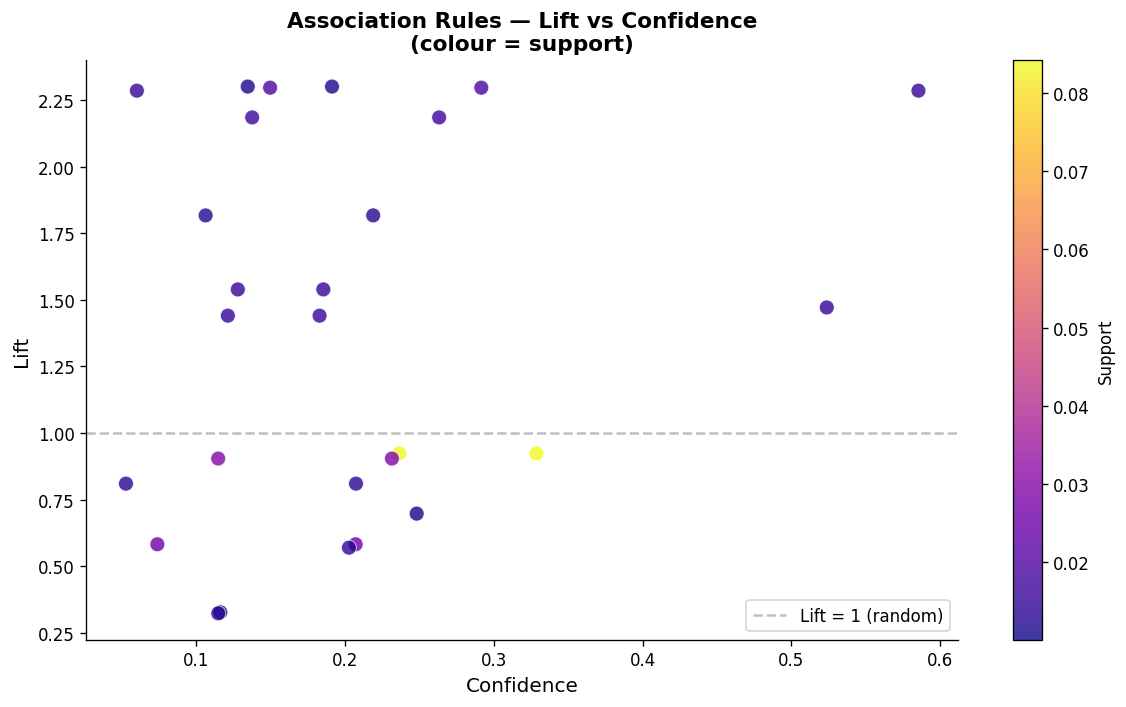

In [8]:
# ── Cell 8: Visualize — Lift vs Confidence Scatter ─────────────────────
fig, ax = plt.subplots(figsize=(10, 6))
sc = ax.scatter(rules['confidence'], rules['lift'], c=rules['support'],
                cmap='plasma', s=80, alpha=0.8, edgecolors='white', linewidths=0.5)
plt.colorbar(sc, ax=ax, label='Support')
ax.set_xlabel('Confidence', fontsize=12)
ax.set_ylabel('Lift', fontsize=12)
ax.set_title('Association Rules — Lift vs Confidence\n(colour = support)', fontsize=13, fontweight='bold')
ax.axhline(1, color='gray', linestyle='--', alpha=0.5, label='Lift = 1 (random)')
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('viz_lift_confidence.png', bbox_inches='tight')
plt.show()

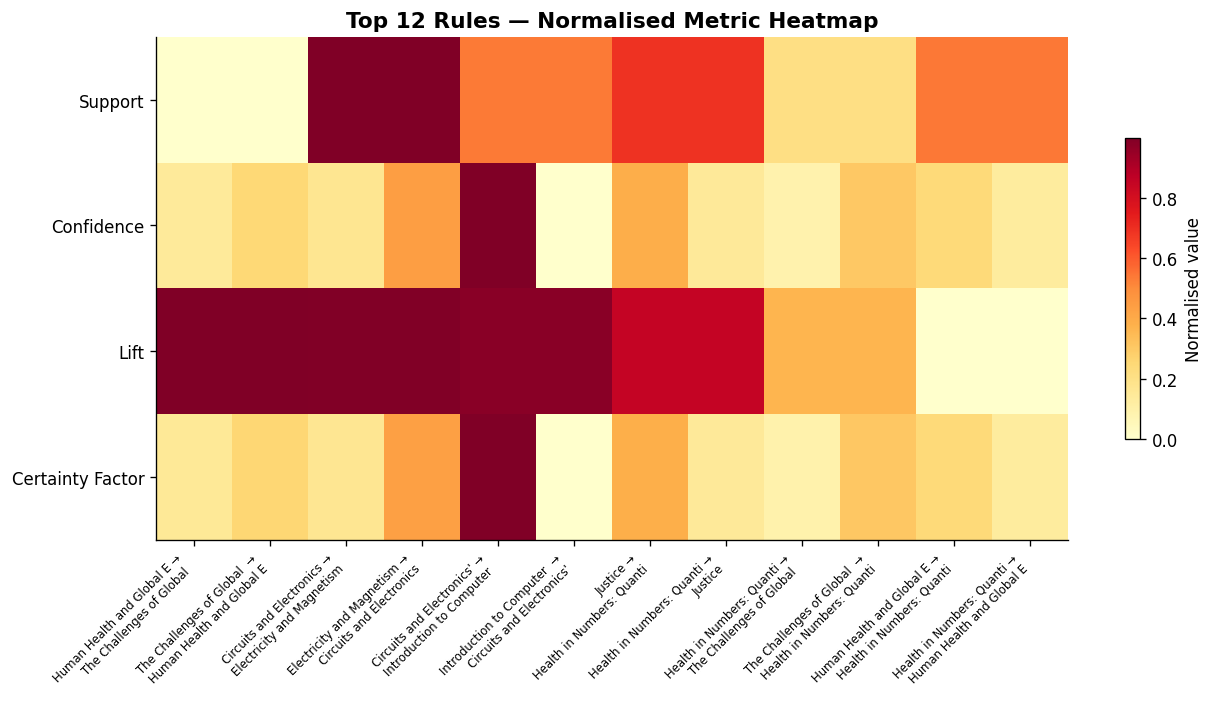

In [9]:
# ── Cell 9: Visualize — Top Rules Heatmap ───────────────────────────────
import ast, re
def clean_name(s):
    return re.sub(r"frozenset\(\{'|'\}\)", '', s).strip()

top_rules = rules.head(12).copy()
top_rules['ant_clean'] = top_rules['antecedents'].apply(clean_name)
top_rules['con_clean'] = top_rules['consequents'].apply(clean_name)
top_rules['label'] = top_rules['ant_clean'].str[:25] + ' →\n' + top_rules['con_clean'].str[:25]

fig, ax = plt.subplots(figsize=(11, 6))
metrics = top_rules[['support','confidence','lift','certainty_factor']].values.T
metrics_norm = (metrics - metrics.min(axis=1, keepdims=True)) / \
               (metrics.max(axis=1, keepdims=True) - metrics.min(axis=1, keepdims=True) + 1e-9)
im = ax.imshow(metrics_norm, cmap='YlOrRd', aspect='auto')
ax.set_xticks(range(len(top_rules)))
ax.set_xticklabels(top_rules['label'], rotation=45, ha='right', fontsize=7)
ax.set_yticks(range(4))
ax.set_yticklabels(['Support','Confidence','Lift','Certainty Factor'], fontsize=10)
ax.set_title('Top 12 Rules — Normalised Metric Heatmap', fontsize=13, fontweight='bold')
plt.colorbar(im, ax=ax, shrink=0.6, label='Normalised value')
plt.tight_layout()
plt.savefig('viz_rules_heatmap.png', bbox_inches='tight')
plt.show()

In [10]:
# ── Cell 10: FP-GROWTH ───────────────────────────────────────────────────
fp_frequent = fpgrowth(df_te, min_support=0.01, use_colnames=True)
fp_frequent['length'] = fp_frequent['itemsets'].apply(len)
fp_frequent['count'] = (fp_frequent['support'] * len(df_te)).round().astype(int)
fp_frequent = fp_frequent.sort_values('support', ascending=False).reset_index(drop=True)

fp_rules = association_rules(fp_frequent, metric='confidence', min_threshold=0.05)
fp_rules['certainty_factor'] = (fp_rules['confidence'] - fp_rules['support']) / (1 - fp_rules['support'])
fp_rules['count'] = (fp_rules['support'] * len(df_te)).round().astype(int)
fp_rules['antecedents'] = fp_rules['antecedents'].apply(str)
fp_rules['consequents'] = fp_rules['consequents'].apply(str)
fp_rules = fp_rules.sort_values('lift', ascending=False).reset_index(drop=True)
print(f'FP-Growth itemsets: {len(fp_frequent)}, rules: {len(fp_rules)}')
fp_rules[['antecedents','consequents','support','confidence','lift','leverage','conviction','certainty_factor','count']].head(8)

FP-Growth itemsets: 27, rules: 27


,antecedents,consequents,support,confidence,lift,leverage,conviction,certainty_factor,count
0,frozenset({'Human Health and Global Environmen...,frozenset({'The Challenges of Global Poverty'}),0.011185,0.134589,2.301257,0.006325,1.087940,0.124800,5330
1,frozenset({'The Challenges of Global Poverty'}),frozenset({'Human Health and Global Environmen...,0.011185,0.191245,2.301257,0.006325,1.133712,0.182097,5330
2,frozenset({'Circuits and Electronics'}),frozenset({'Electricity and Magnetism'}),0.018998,0.149659,2.296996,0.010727,1.099377,0.133191,9053
3,frozenset({'Electricity and Magnetism'}),frozenset({'Circuits and Electronics'}),0.018998,0.291581,2.296996,0.010727,1.232406,0.277862,9053
4,"frozenset({'Circuits and Electronics', 'CS50: ...",frozenset({'Introduction to Computer Science a...,0.015390,0.585362,2.285806,0.008657,1.794130,0.578881,7334
5,frozenset({'Introduction to Computer Science a...,"frozenset({'Circuits and Electronics', 'CS50: ...",0.015390,0.060098,2.285806,0.008657,1.035968,0.045407,7334
6,frozenset({'Justice'}),frozenset({'Health in Numbers: Quantitative Me...,0.016574,0.263249,2.185253,0.008989,1.193801,0.250832,7898
7,frozenset({'Health in Numbers: Quantitative Me...,frozenset({'Justice'}),0.016574,0.137581,2.185253,0.008989,1.086527,0.123047,7898


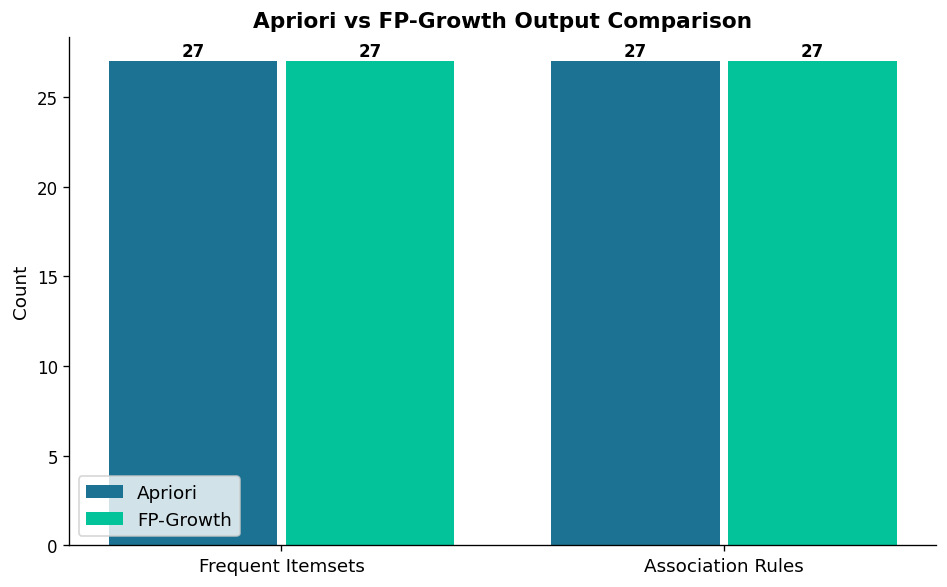

In [11]:
# ── Cell 11: Visualize — Apriori vs FP-Growth Comparison ────────────────
fig, ax = plt.subplots(figsize=(8, 5))
x = ['Frequent Itemsets', 'Association Rules']
apriori_vals = [len(frequent_itemsets), len(rules)]
fp_vals = [len(fp_frequent), len(fp_rules)]
x_pos = np.arange(len(x))
bars1 = ax.bar(x_pos - 0.2, apriori_vals, 0.38, label='Apriori', color='#1C7293')
bars2 = ax.bar(x_pos + 0.2, fp_vals, 0.38, label='FP-Growth', color='#02C39A')
for b in list(bars1) + list(bars2):
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.3,
            str(int(b.get_height())), ha='center', fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels(x, fontsize=11)
ax.set_ylabel('Count', fontsize=11)
ax.set_title('Apriori vs FP-Growth Output Comparison', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig('viz_apriori_vs_fpgrowth.png', bbox_inches='tight')
plt.show()

In [12]:
# ── Cell 12: PageRank — Build Course Co-enrollment Graph ─────────────────
G = nx.Graph()
all_courses = enrollments['course_name'].unique().tolist()
G.add_nodes_from(all_courses)

edge_weights = {}
for tx in transactions:
    unique_courses = list(set(tx))
    for i in range(len(unique_courses)):
        for j in range(i+1, len(unique_courses)):
            pair = tuple(sorted([unique_courses[i], unique_courses[j]]))
            edge_weights[pair] = edge_weights.get(pair, 0) + 1

for (c1, c2), w in edge_weights.items():
    G.add_edge(c1, c2, weight=w)

pagerank = nx.pagerank(G, weight='weight')
pr_df = pd.DataFrame({'course_name': list(pagerank.keys()),
                       'pagerank_score': list(pagerank.values())})
pr_df = pr_df.sort_values('pagerank_score', ascending=False).reset_index(drop=True)
print('Top PageRank Courses:')
pr_df.head(10)

Top PageRank Courses:


,course_name,pagerank_score
0,CS50: Introduction to Computer Science,0.170560
1,Introduction to Computer Science and Programming,0.156499
2,Circuits and Electronics,0.098793
3,Health in Numbers: Quantitative Methods,0.091003
4,Electricity and Magnetism,0.080722
5,Human Health and Global Environmental Change,0.074326
6,Justice,0.062904
7,The Challenges of Global Poverty,0.056343
8,Introduction to Biology: The Secret of Life,0.055124
9,Introduction to Solid State Chemistry,0.052664


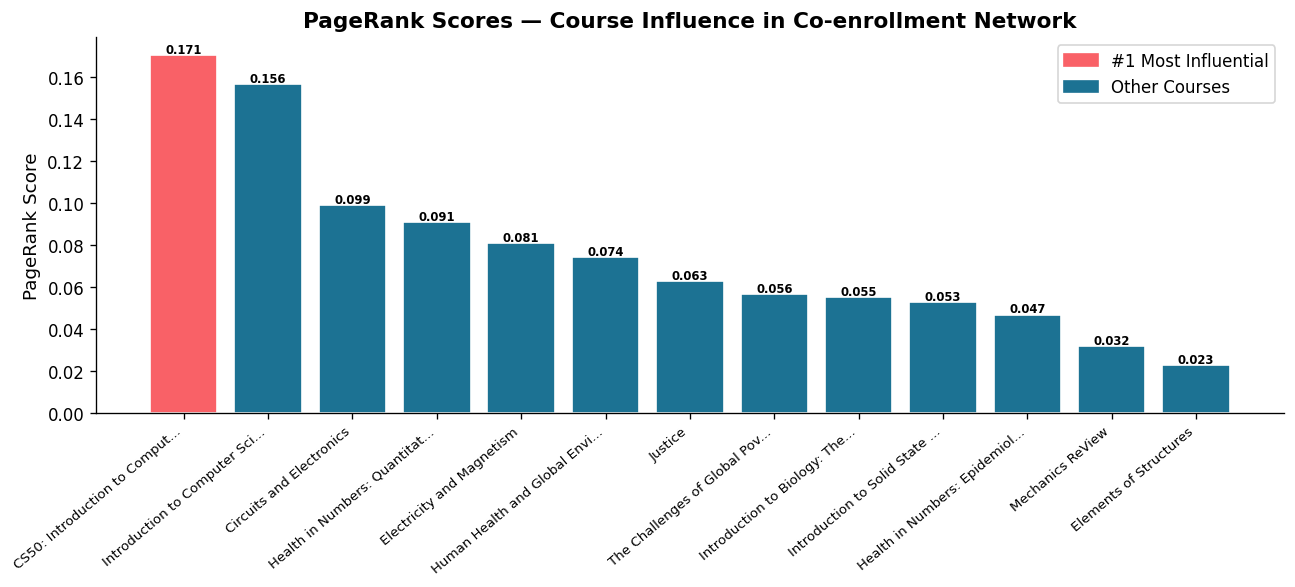

In [13]:
# ── Cell 13: Visualize — PageRank Bar Chart ─────────────────────────────
fig, ax = plt.subplots(figsize=(11, 5))
colors = ['#F96167' if i == 0 else '#1C7293' for i in range(len(pr_df))]
bars = ax.bar(range(len(pr_df)), pr_df['pagerank_score'], color=colors, edgecolor='white')
ax.set_xticks(range(len(pr_df)))
ax.set_xticklabels([c[:28] + '...' if len(c) > 28 else c for c in pr_df['course_name']],
                   rotation=40, ha='right', fontsize=8)
ax.set_ylabel('PageRank Score', fontsize=11)
ax.set_title('PageRank Scores — Course Influence in Co-enrollment Network',
             fontsize=13, fontweight='bold')
for bar, score in zip(bars, pr_df['pagerank_score']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
            f'{score:.3f}', ha='center', fontsize=7, fontweight='bold')
ax.legend(handles=[mpatches.Patch(color='#F96167', label='#1 Most Influential'),
                   mpatches.Patch(color='#1C7293', label='Other Courses')], fontsize=10)
plt.tight_layout()
plt.savefig('viz_pagerank.png', bbox_inches='tight')
plt.show()

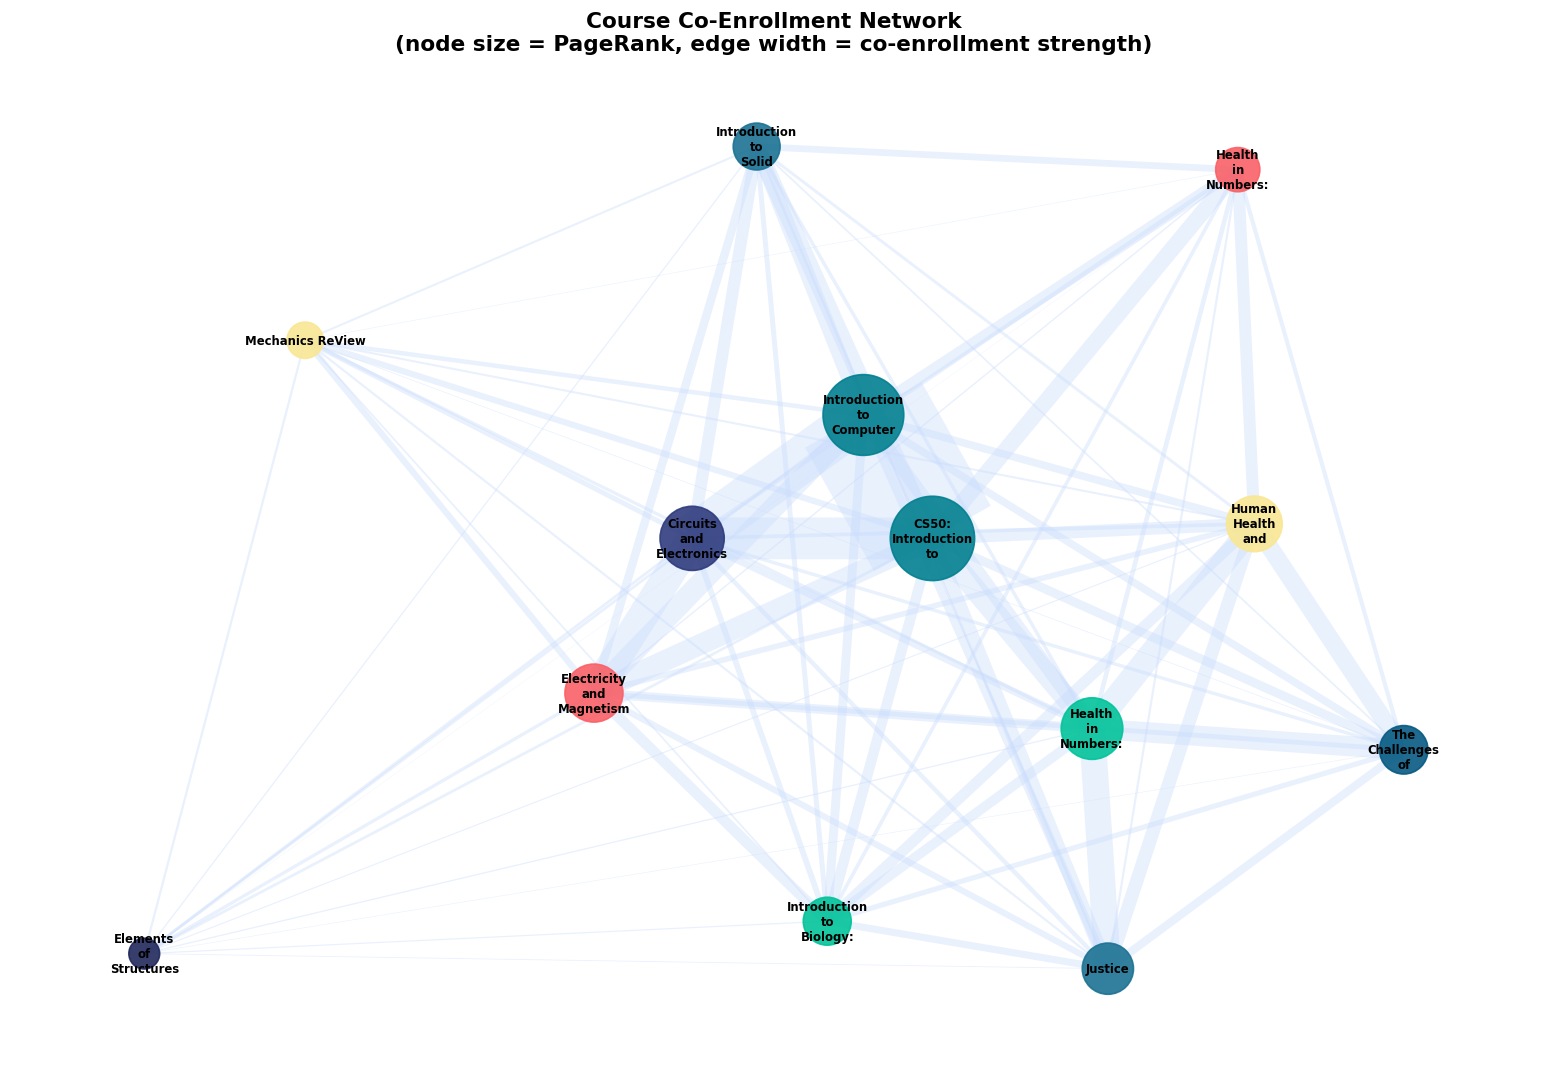

In [14]:
# ── Cell 14: Visualize — Course Network Graph ───────────────────────────
fig, ax = plt.subplots(figsize=(13, 9))
pos = nx.spring_layout(G, seed=42, k=2.5)

# Node sizes scaled by PageRank
node_sizes = [pagerank[n] * 15000 for n in G.nodes()]
edge_weights_list = [G[u][v]['weight'] / 500 for u, v in G.edges()]

nx.draw_networkx_edges(G, pos, width=edge_weights_list, alpha=0.4, edge_color='#CADCFC', ax=ax)
node_colors = [PALETTE[i % len(PALETTE)] for i in range(G.number_of_nodes())]
nx.draw_networkx_nodes(G, pos, node_size=node_sizes, node_color=node_colors,
                       alpha=0.9, ax=ax)
short_labels = {n: ('\n'.join(n.split()[:3]) if len(n) > 20 else n) for n in G.nodes()}
nx.draw_networkx_labels(G, pos, labels=short_labels, font_size=7, font_weight='bold', ax=ax)
ax.set_title('Course Co-Enrollment Network\n(node size = PageRank, edge width = co-enrollment strength)',
             fontsize=13, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.savefig('viz_course_network.png', bbox_inches='tight', dpi=150)
plt.show()

In [15]:
# ── Cell 15: Save All Task 1 Outputs ────────────────────────────────────
frequent_itemsets.to_csv('frequent_itemsets.csv', index=False)
rules_save = rules.copy()
rules_save.to_csv('association_rules.csv', index=False)
fp_frequent.to_csv('fp_frequent_itemsets.csv', index=False)
fp_rules.to_csv('fp_rules.csv', index=False)

edges_df = pd.DataFrame([(u,v,d['weight']) for u,v,d in G.edges(data=True)],
                         columns=['source','target','weight']).sort_values('weight', ascending=False)
edges_df.to_csv('course_graph_edges.csv', index=False)
pr_df['rank'] = pr_df.index + 1
pr_df.to_csv('pagerank_scores.csv', index=False)

print('✅ All Task 1 CSV files saved:')
print('  • frequent_itemsets.csv')
print('  • association_rules.csv')
print('  • fp_frequent_itemsets.csv')
print('  • fp_rules.csv')
print('  • course_graph_edges.csv')
print('  • pagerank_scores.csv')

✅ All Task 1 CSV files saved:
  • frequent_itemsets.csv
  • association_rules.csv
  • fp_frequent_itemsets.csv
  • fp_rules.csv
  • course_graph_edges.csv
  • pagerank_scores.csv


## 🧠 High-Demand Skills Analysis

This section extends Task 1 with the project requirement: *"supported by insights into high-demand skills and common course sequences."*

Skills are extracted from each course's `course_description` using a curated keyword taxonomy, then ranked by a **demand score** combining total enrolments (60%) and PageRank (40%). This part runs **after** the main analysis and reuses the `enrollments` DataFrame and the `pagerank` dict already computed above — it does **not** modify any earlier results.


In [16]:
# ── Cell 16: High-Demand Skill Extraction ──────────────────────────────
# Generates: high_demand_skills.csv  (saved to /content/ for Colab)

SKILL_TAXONOMY = {
    'Algorithms':            ['algorithm'],
    'Data Structures':       ['data structure'],
    'Software Engineering':  ['software engineering', 'debugging', 'program efficiency'],
    'Python':                ['python'],
    'C Programming':         ['using c,'],
    'Databases & SQL':       ['sql'],
    'Web Development':       ['web development'],
    'Computational Thinking':['computational thinking'],
    'Public Health':         ['public health'],
    'Epidemiology':          ['epidemiology'],
    'Study Design':          ['study design'],
    'Statistics':            ['biostatistics', 'statistical'],
    'Electrical Engineering':['electrical engineering'],
    'Signal Processing':     ['signal processing'],
    'Circuit Analysis':      ['circuit analysis'],
    'Political Theory':      ['political'],
    'Regression Analysis':   ['regression'],
    'Hypothesis Testing':    ['hypothesis testing'],
    'Probability':           ['probability'],
    'Chemistry':             ['chemistry'],
    'Environmental Health':  ['environmental'],
    'Infectious Diseases':   ['infectious'],
    'Food Security':         ['food security'],
    'Electromagnetism':      ['electromagnetism'],
    'Ethics & Philosophy':   ['ethical', 'ethics'],
    'Classical Mechanics':   ['classical mechanics', 'kinematics', 'kinetics'],
    'Development Economics': ['poverty traps', 'microfinance'],
    'Field Research':        ['field research'],
    'Education Economics':   ['education,'],
    'Genetics':              ['genetics'],
    'Molecular Biology':     ['molecular'],
    'Materials Science':     ['materials science'],
    'Thermodynamics':        ['thermodynamics'],
    'Structural Analysis':   ['structural'],
}

def extract_skills(description):
    if not isinstance(description, str):
        return []
    desc_lower = description.lower()
    return [skill for skill, kws in SKILL_TAXONOMY.items()
            if any(kw in desc_lower for kw in kws)]

# Build per-course table: enrolments + pagerank + description + skills
pr_lookup = pagerank  # course_name -> pagerank score (from Cell 12)

course_info = (
    enrollments.groupby('course_name')
               .agg(total_enrollments=('userid_DI', 'nunique'),
                    description=('course_description', 'first'))
               .reset_index()
)
course_info['pagerank'] = course_info['course_name'].map(pr_lookup).fillna(0)
course_info['skills']   = course_info['description'].apply(extract_skills)

# Course-level min-max normalisation
e_min, e_max = course_info['total_enrollments'].min(), course_info['total_enrollments'].max()
p_min, p_max = course_info['pagerank'].min(),          course_info['pagerank'].max()
course_info['enrol_norm']   = (course_info['total_enrollments'] - e_min) / (e_max - e_min)
course_info['pr_norm']      = (course_info['pagerank']          - p_min) / (p_max - p_min)
course_info['course_score'] = 0.6 * course_info['enrol_norm'] + 0.4 * course_info['pr_norm']

# Skill-level aggregation: sum enrolments, avg pagerank, MAX course_score
skill_records = []
for _, row in course_info.iterrows():
    for skill in row['skills']:
        skill_records.append({
            'skill':        skill,
            'course':       row['course_name'],
            'enrollments':  row['total_enrollments'],
            'pagerank':     row['pagerank'],
            'course_score': row['course_score'],
        })

skill_df = pd.DataFrame(skill_records)
skills_agg = (
    skill_df.groupby('skill')
            .agg(total_enrollments=('enrollments', 'sum'),
                 avg_pagerank=('pagerank', 'mean'),
                 demand_score=('course_score', 'max'),
                 courses_count=('course', 'nunique'),
                 taught_in_courses=('course', lambda x: ' | '.join(sorted(x.unique()))))
            .reset_index()
)
skills_agg['demand_score'] = skills_agg['demand_score'].round(4)
skills_agg = skills_agg.sort_values('demand_score', ascending=False).reset_index(drop=True)
skills_agg['rank'] = skills_agg.index + 1

OUT_COLS = ['rank','skill','total_enrollments','avg_pagerank','demand_score',
            'courses_count','taught_in_courses']
skills_agg[OUT_COLS].to_csv('/content/high_demand_skills.csv', index=False)
print(f'Skills extracted: {len(skills_agg)}')
print('💾 Saved: /content/high_demand_skills.csv')
skills_agg[OUT_COLS].head(15)


Skills extracted: 34
💾 Saved: /content/high_demand_skills.csv


,rank,skill,total_enrollments,avg_pagerank,demand_score,courses_count,taught_in_courses
0,1,Algorithms,291654,0.163530,1.0000,2,CS50: Introduction to Computer Science | Intro...
1,2,C Programming,169621,0.170560,1.0000,1,CS50: Introduction to Computer Science
2,3,Databases & SQL,169621,0.170560,1.0000,1,CS50: Introduction to Computer Science
3,4,Data Structures,291654,0.163530,1.0000,2,CS50: Introduction to Computer Science | Intro...
4,5,Software Engineering,291654,0.163530,1.0000,2,CS50: Introduction to Computer Science | Intro...
5,6,Python,291654,0.163530,1.0000,2,CS50: Introduction to Computer Science | Intro...
6,7,Web Development,169621,0.170560,1.0000,1,CS50: Introduction to Computer Science
7,8,Computational Thinking,122033,0.156499,0.7878,1,Introduction to Computer Science and Programming
8,9,Electrical Engineering,60491,0.098793,0.4065,1,Circuits and Electronics
9,10,Circuit Analysis,60491,0.098793,0.4065,1,Circuits and Electronics


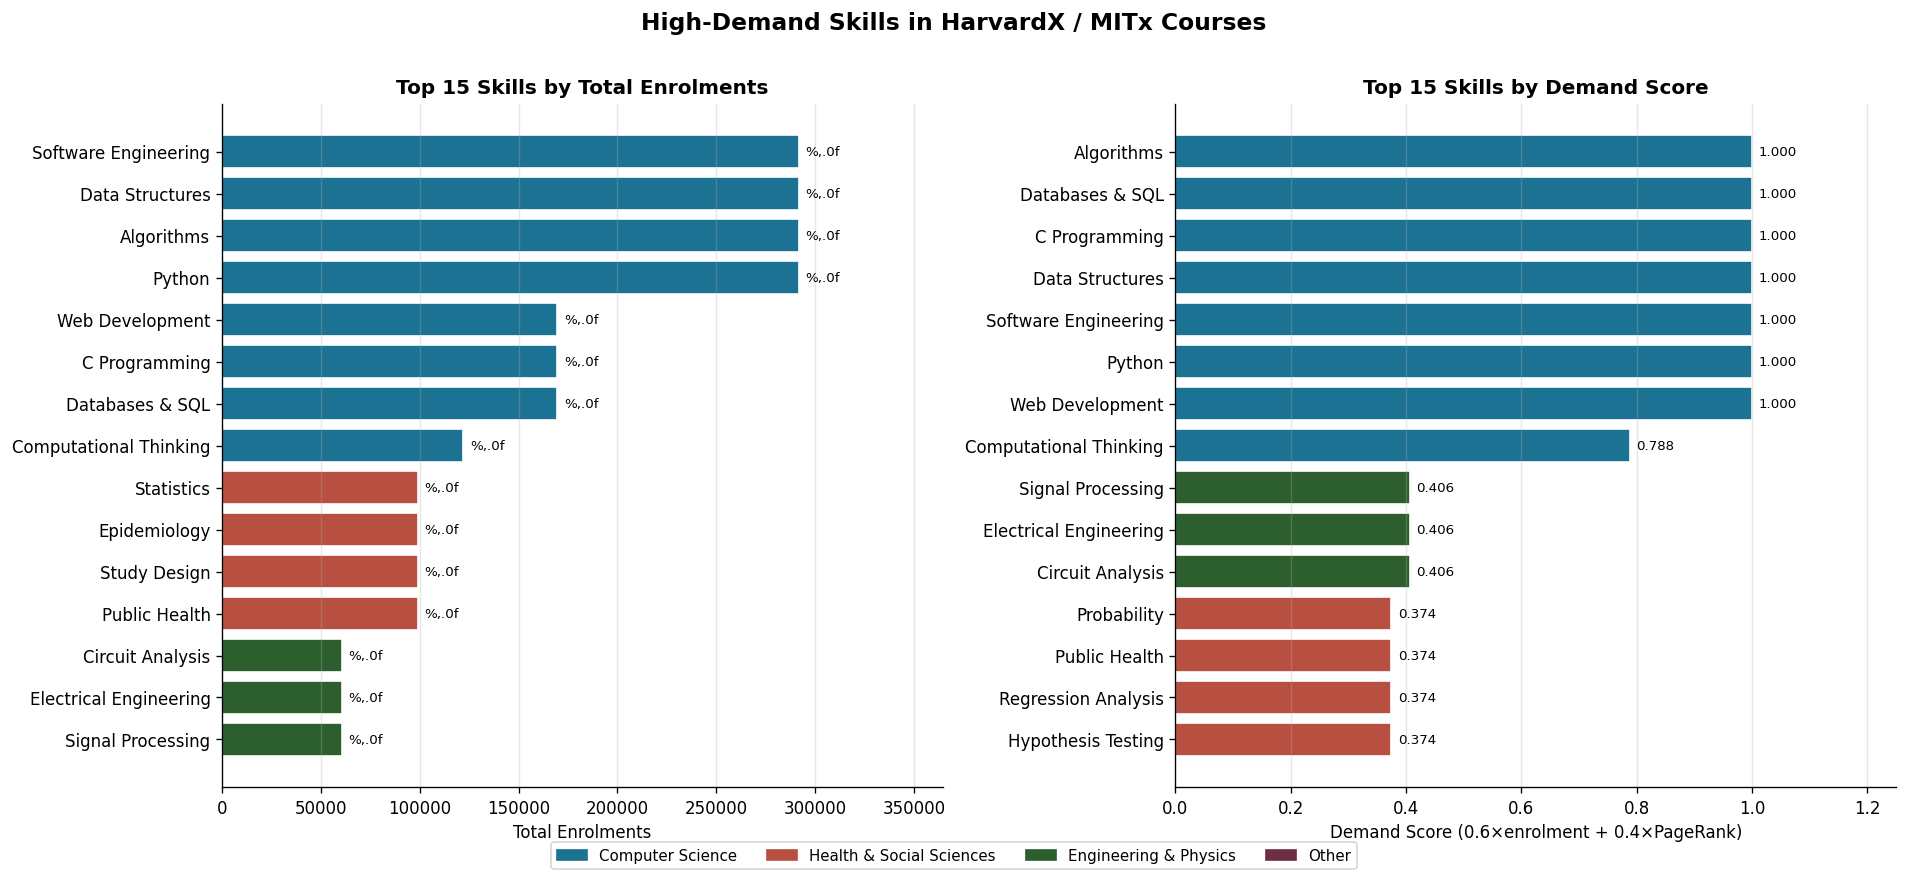

💾 Saved: /content/viz_high_demand_skills.png


In [17]:
# ── Cell 17: High-Demand Skills Visualisation ──────────────────────────
CS_SKILLS     = {'Algorithms','Data Structures','Software Engineering','Python',
                 'C Programming','Databases & SQL','Web Development',
                 'Computational Thinking'}
HEALTH_SKILLS = {'Public Health','Epidemiology','Study Design','Statistics',
                 'Regression Analysis','Hypothesis Testing','Probability',
                 'Environmental Health','Infectious Diseases','Food Security',
                 'Development Economics','Field Research','Education Economics',
                 'Genetics','Molecular Biology'}
ENG_SKILLS    = {'Electrical Engineering','Signal Processing','Circuit Analysis',
                 'Electromagnetism','Classical Mechanics','Materials Science',
                 'Thermodynamics','Structural Analysis','Chemistry'}

def domain_color(skill):
    if skill in CS_SKILLS:     return '#1C7293'
    if skill in HEALTH_SKILLS: return '#B85042'
    if skill in ENG_SKILLS:    return '#2C5F2D'
    return '#6D2E46'

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# ── Left: Top 15 by total enrolments ─────────────────────────────────
top_e = skills_agg.nlargest(15, 'total_enrollments').sort_values('total_enrollments')
c1 = [domain_color(s) for s in top_e['skill']]
b1 = axes[0].barh(top_e['skill'], top_e['total_enrollments'], color=c1, edgecolor='white')
axes[0].bar_label(b1, fmt='%,.0f', padding=4, fontsize=8)
axes[0].set_xlabel('Total Enrolments')
axes[0].set_title('Top 15 Skills by Total Enrolments', fontsize=12, fontweight='bold')
axes[0].set_xlim(0, top_e['total_enrollments'].max() * 1.25)
axes[0].grid(axis='x', alpha=0.3)

# ── Right: Top 15 by demand score ───────────────────────────────────
top_d = skills_agg.nlargest(15, 'demand_score').sort_values('demand_score')
c2 = [domain_color(s) for s in top_d['skill']]
b2 = axes[1].barh(top_d['skill'], top_d['demand_score'], color=c2, edgecolor='white')
axes[1].bar_label(b2, fmt='%.3f', padding=4, fontsize=8)
axes[1].set_xlabel('Demand Score (0.6×enrolment + 0.4×PageRank)')
axes[1].set_title('Top 15 Skills by Demand Score', fontsize=12, fontweight='bold')
axes[1].set_xlim(0, top_d['demand_score'].max() * 1.25)
axes[1].grid(axis='x', alpha=0.3)

legend_patches = [
    mpatches.Patch(color='#1C7293', label='Computer Science'),
    mpatches.Patch(color='#B85042', label='Health & Social Sciences'),
    mpatches.Patch(color='#2C5F2D', label='Engineering & Physics'),
    mpatches.Patch(color='#6D2E46', label='Other'),
]
fig.legend(handles=legend_patches, loc='lower center', ncol=4,
           fontsize=9, frameon=True, bbox_to_anchor=(0.5, -0.02))
plt.suptitle('High-Demand Skills in HarvardX / MITx Courses',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('/content/viz_high_demand_skills.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Saved: /content/viz_high_demand_skills.png')


## 📁 Summary of Task 1 Outputs

| File | Description |
|------|-------------|
| `frequent_itemsets.csv` | Apriori frequent itemsets |
| `association_rules.csv` | Apriori association rules |
| `fp_frequent_itemsets.csv` | FP-Growth frequent itemsets |
| `fp_rules.csv` | FP-Growth association rules |
| `course_graph_edges.csv` | Weighted co-enrolment edge list |
| `pagerank_scores.csv` | PageRank scores per course |
| `high_demand_skills.csv` | Ranked skills + demand score |
| `viz_*.png` | All generated visualisations |
